In [ ]:
%%writefile requirements.txt
tensorflow==2.16.2
keras==3.3.3
scikeras==0.13.0
scikit-learn==1.5.2
numpy==1.26.4
matplotlib==3.8.4
seaborn==0.13.2
pandas==2.2.2
protobuf==4.25.3
ml-dtypes==0.3.2
tensorboard==2.16.2

Overwriting requirements.txt


In [ ]:
!pip install --upgrade pip -q
!pip uninstall -y tensorflow keras tf-keras tensorflow-text tensorboard numpy protobuf ml-dtypes > /dev/null 2>&1
!pip install --force-reinstall -r requirements.txt

  Using cached tensorflow-2.16.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached keras-3.3.3-py3-none-any.whl.metadata (5.7 kB)
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached matplotlib-3.8.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.8 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached protobuf-4.25.3-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
  Using

In [ ]:
!pip uninstall -y jax jaxlib

In [ ]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import sklearn

print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("Seaborn:", sns.__version__)
print("sklearn:", sklearn.__version__)

NumPy: 1.26.4
TensorFlow: 2.16.2
Seaborn: 0.13.2
sklearn: 1.5.2


In [ ]:
# Cell 0b: Install Times New Roman font (not preinstalled on Colab's Linux VM)
# Verifies the font actually registers with matplotlib; falls back to
# Liberation Serif (metrically compatible with Times) if it doesn't.
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

subprocess.run(
    'echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections',
    shell=True
)

result = subprocess.run(
    "apt-get update -qq && apt-get install -y ttf-mscorefonts-installer",
    shell=True,
    capture_output=True,
    text=True
)

print(result.stdout[-1000:])
print(result.stderr[-1000:])

subprocess.run("rm -rf ~/.cache/matplotlib", shell=True)
subprocess.run("fc-cache -f", shell=True, capture_output=True)

for f in fm.findSystemFonts():
    if "times" in f.lower():
        fm.fontManager.addfont(f)

available = {f.name for f in fm.fontManager.ttflist}

print("\nIs 'Times New Roman' actually installed?",
      "Times New Roman" in available)

if "Times New Roman" in available:
    plt.rcParams["font.family"] = "Times New Roman"
else:
    subprocess.run(
        "apt-get install -y fonts-liberation",
        shell=True,
        capture_output=True
    )

    subprocess.run(
        "rm -rf ~/.cache/matplotlib && fc-cache -f",
        shell=True,
        capture_output=True
    )

    for f in fm.findSystemFonts():
        if "liberationserif" in f.lower():
            fm.fontManager.addfont(f)

    plt.rcParams["font.family"] = "Liberation Serif"

    print(
        "Times New Roman unavailable — using Liberation Serif instead."
    )

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.titlesize"] = 14

print("\nFinal font:", plt.rcParams["font.family"])
print("Now go to: Runtime -> Restart runtime, then continue from Cell 1.")

bolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link

Processing triggers for man-db (2.10.2-1) ...


In [ ]:
# Cell 1: Imports and Global Setup
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from scikeras.wrappers import KerasClassifier

# ---- Global font settings: Times New Roman for ALL plot text ----
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif', 'Times', 'DejaVu Serif']
mpl.rcParams['mathtext.fontset'] = 'stix'   # Times-like font for any math text
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['font.size'] = 11

# Helper: save every figure as .eps at 600 DPI
def save_eps(fig, filename):
    fig.savefig(f"{filename}.eps", format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved: {filename}.eps")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print(f"Training images shape : {x_train_raw.shape}")
print(f"Training labels shape : {y_train_raw.shape}")
print(f"Testing images shape  : {x_test_raw.shape}")
print(f"Testing labels shape  : {y_test_raw.shape}")
print(f"Number of classes     : {len(np.unique(y_train_raw))}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)
Number of classes     : 10


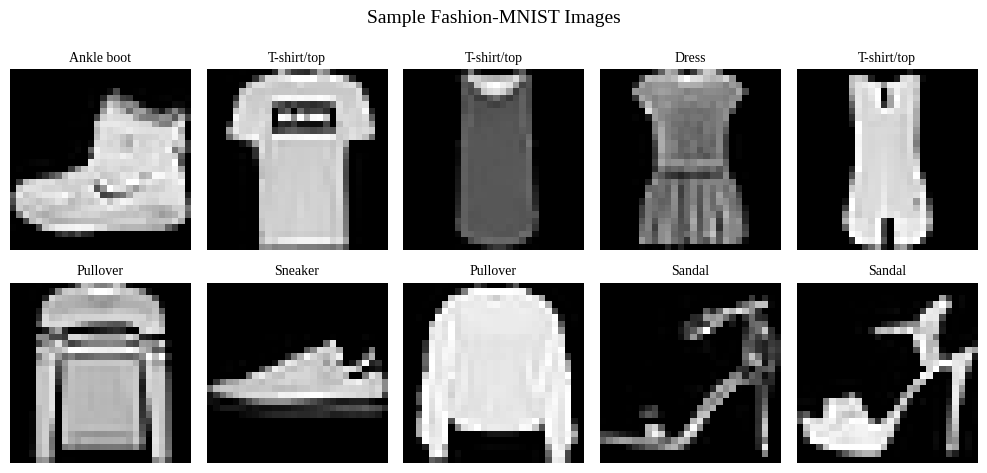

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_raw[i]], fontsize=10, fontfamily='serif')
    ax.axis('off')
fig.suptitle("Sample Fashion-MNIST Images", fontfamily='serif', fontsize=14)
plt.tight_layout()
plt.savefig("plot1_sample_images.pdf", bbox_inches="tight")
#save_eps(fig, "plot1_sample_images")
plt.show()

/tmp/ipykernel_8681/577243585.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontfamily='serif')


Saved: plot2_class_distribution.eps


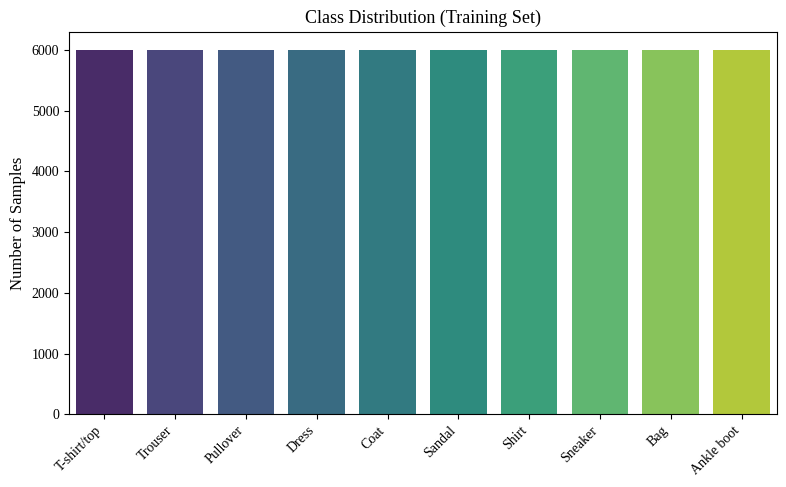

In [ ]:
unique, counts = np.unique(y_train_raw, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=[CLASS_NAMES[i] for i in unique], y=counts,
            hue=[CLASS_NAMES[i] for i in unique], palette="viridis",
            legend=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontfamily='serif')
ax.set_ylabel("Number of Samples", fontfamily='serif')
ax.set_title("Class Distribution (Training Set)", fontfamily='serif')
plt.tight_layout()
save_eps(fig, "plot2_class_distribution")
plt.show()

In [ ]:
print(f"Shape before preprocessing (train): {x_train_raw.shape}")
print(f"Shape before preprocessing (test) : {x_test_raw.shape}")

x_train = x_train_raw.reshape(x_train_raw.shape[0], 28 * 28).astype('float32')
x_test = x_test_raw.reshape(x_test_raw.shape[0], 28 * 28).astype('float32')

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(f"Shape after preprocessing (train X): {x_train.shape}")
print(f"Shape after preprocessing (test X) : {x_test.shape}")
print(f"Shape after preprocessing (train y): {y_train.shape}")
print(f"Shape after preprocessing (test y) : {y_test.shape}")

Shape before preprocessing (train): (60000, 28, 28)
Shape before preprocessing (test) : (10000, 28, 28)
Shape after preprocessing (train X): (60000, 784)
Shape after preprocessing (test X) : (10000, 784)
Shape after preprocessing (train y): (60000, 10)
Shape after preprocessing (test y) : (10000, 10)


In [ ]:
#(784 -> 128 -> 64 -> 10)
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()
history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8185 - loss: 0.5062 - val_accuracy: 0.8538 - val_loss: 0.3948
Epoch 2/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8647 - loss: 0.3695 - val_accuracy: 0.8587 - val_loss: 0.3820
Epoch 3/20
1688/1688 - 4s - 2ms/step - accuracy: 0.8769 - loss: 0.3316 - val_accuracy: 0.8632 - val_loss: 0.3710
Epoch 4/20
1688/1688 - 4s - 2ms/step - accuracy: 0.8863 - loss: 0.3074 - val_accuracy: 0.8667 - val_loss: 0.3661
Epoch 5/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8926 - loss: 0.2894 - val_accuracy: 0.8730 - val_loss: 0.3532
Epoch 6/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8981 - loss: 0.2735 - val_accuracy: 0.8692 - val_loss: 0.3565
Epoch 7/20
1688/1688 - 4s - 2ms/step - accuracy: 0.9019 - loss: 0.2606 - val_accuracy: 0.8620 - val_loss: 0.3737
Epoch 8/20
1688/1688 - 5s - 3ms/step - accuracy: 0.9051 - loss: 0.2497 - val_accuracy: 0.8725 - val_loss: 0.3546
Epoch 9/20
1688/1688 - 6s - 3ms/step - accuracy: 0.9096 - loss: 0.2389 - val_accuracy: 0.8740 - 

Saved: plot3_4_accuracy_vs_epoch.eps


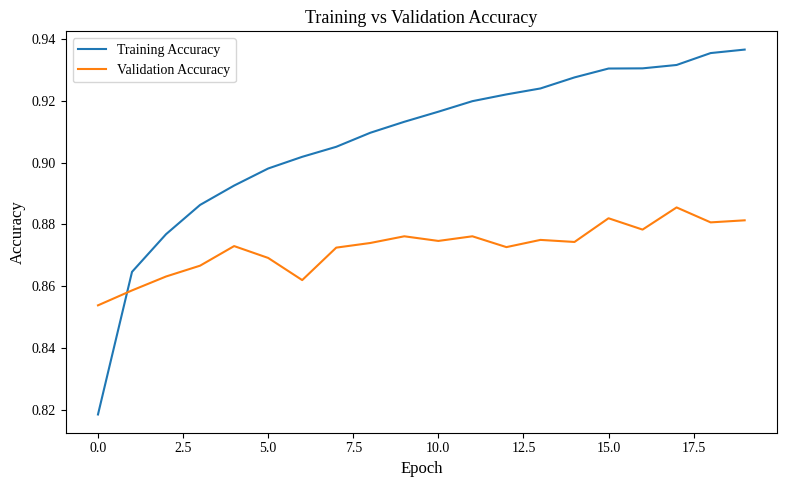

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['accuracy'], label='Training Accuracy')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax.set_xlabel("Epoch", fontfamily='serif')
ax.set_ylabel("Accuracy", fontfamily='serif')
ax.set_title("Training vs Validation Accuracy", fontfamily='serif')
ax.legend(prop={'family': 'serif'})
plt.tight_layout()
save_eps(fig, "plot3_4_accuracy_vs_epoch")
plt.show()

Saved: plot5_6_loss_vs_epoch.eps


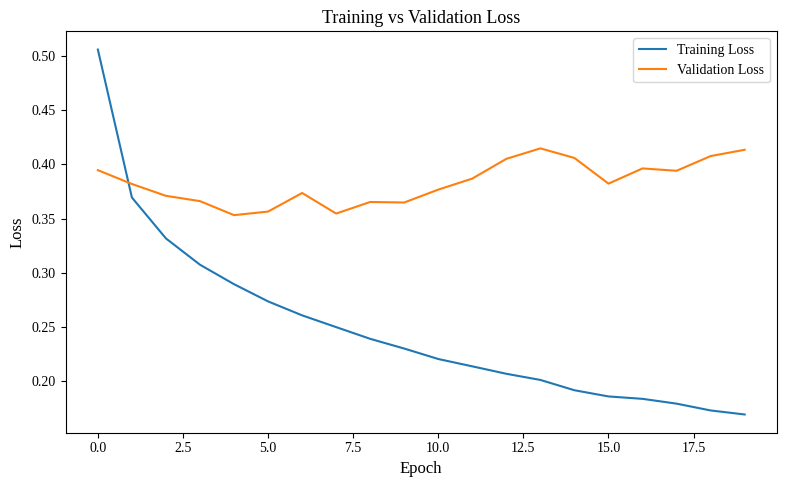

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel("Epoch", fontfamily='serif')
ax.set_ylabel("Loss", fontfamily='serif')
ax.set_title("Training vs Validation Loss", fontfamily='serif')
ax.legend(prop={'family': 'serif'})
plt.tight_layout()
save_eps(fig, "plot5_6_loss_vs_epoch")
plt.show()

In [ ]:
y_pred_proba = baseline_model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average='macro')
baseline_rec = recall_score(y_true, y_pred, average='macro')
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy : {baseline_acc:.4f}")
print(f"Precision: {baseline_prec:.4f}")
print(f"Recall   : {baseline_rec:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8756
Precision: 0.8776
Recall   : 0.8756
F1-score : 0.8730

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.89      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.76      0.83      0.79      1000
       Dress       0.86      0.90      0.88      1000
        Coat       0.78      0.83      0.80      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.81      0.55      0.65      1000
     Sneaker       0.90      0.96      0.93      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.98      0.90      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



Saved: plot7_confusion_matrix.eps


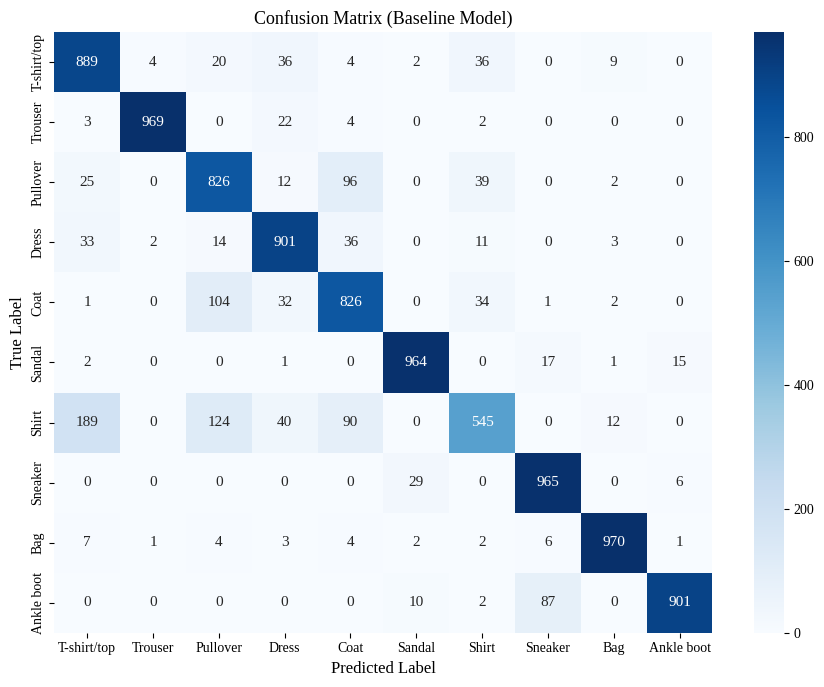

In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'fontfamily': 'serif'}, ax=ax)
ax.set_xlabel("Predicted Label", fontfamily='serif')
ax.set_ylabel("True Label", fontfamily='serif')
ax.set_title("Confusion Matrix (Baseline Model)", fontfamily='serif')
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif')
ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif')
plt.tight_layout()
save_eps(fig, "plot7_confusion_matrix")
plt.show()

In [ ]:
def build_model_for_search(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                            activation='relu', dropout_rate=0.0, meta=None):
    n_features = meta["n_features_in_"] if meta is not None else 784
    n_classes = meta["n_classes_"] if meta is not None else 10

    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(n_classes, activation='softmax'))
    return model


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return keras.optimizers.Adam(learning_rate=learning_rate)
    elif name == 'sgd':
        return keras.optimizers.SGD(learning_rate=learning_rate)
    elif name == 'rmsprop':
        return keras.optimizers.RMSprop(learning_rate=learning_rate)
    raise ValueError(f"Unknown optimizer: {name}")


class MLPClassifier(KerasClassifier):
    """Custom SciKeras wrapper so the optimizer string is translated
    into an actual optimizer instance with the requested learning rate."""

    def __init__(self, hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                 activation='relu', dropout_rate=0.0, optimizer_name='adam',
                 **kwargs):
        self.hidden_layers = hidden_layers
        self.hidden_neurons = hidden_neurons
        self.learning_rate = learning_rate
        self.activation = activation
        self.dropout_rate = dropout_rate
        self.optimizer_name = optimizer_name
        super().__init__(**kwargs)

    def _keras_build_fn(self, compile_kwargs=None):
        model = build_model_for_search(
            hidden_layers=self.hidden_layers,
            hidden_neurons=self.hidden_neurons,
            activation=self.activation,
            dropout_rate=self.dropout_rate,
            meta=self._meta if hasattr(self, "_meta") else None,
        )
        model.compile(
            optimizer=get_optimizer(self.optimizer_name, self.learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

In [ ]:


param_distributions = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5],
}

rng = np.random.RandomState(SEED)
subsample_idx = rng.choice(len(x_train), size=6000, replace=False)
x_search = x_train[subsample_idx]
y_search_labels = y_train_raw[subsample_idx]

keras_clf = MLPClassifier(
    hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
    activation='relu', dropout_rate=0.0, optimizer_name='adam',
    verbose=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv,
    scoring='accuracy',
    n_jobs=1,
    verbose=2,
    random_state=SEED
)

print("Running RandomizedSearchCV with 5-fold cross-validation (20 sampled configurations)...")
random_search.fit(x_search, y_search_labels)

best_params = random_search.best_params_
best_cv_accuracy = random_search.best_score_

print("\nBest Hyperparameters Found:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best Cross-Validation Accuracy: {best_cv_accuracy:.4f}")

Running RandomizedSearchCV with 5-fold cross-validation (20 sampled configurations)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   4.7s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.0s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.5s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   4.6s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.9s
[CV] E

Saved: plot8_hyperparam_search_results.eps


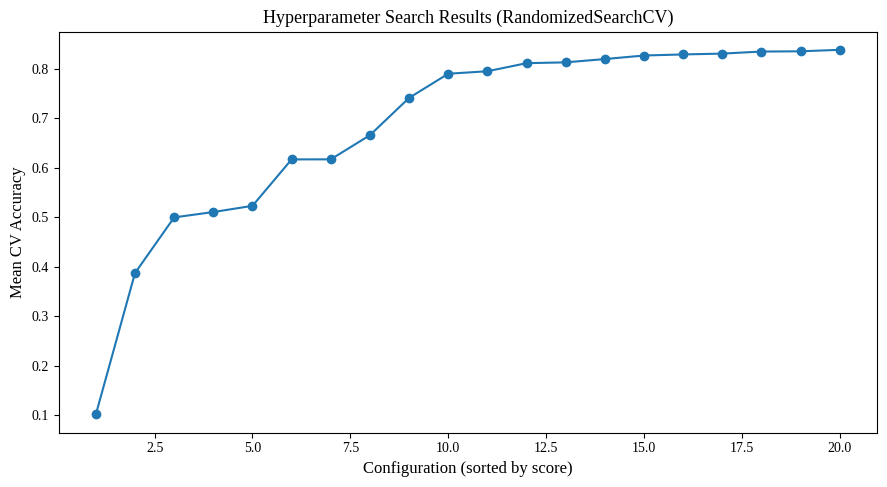

In [ ]:
cv_results = random_search.cv_results_
mean_scores = cv_results['mean_test_score']

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(mean_scores) + 1), sorted(mean_scores), marker='o')
ax.set_xlabel("Configuration (sorted by score)", fontfamily='serif')
ax.set_ylabel("Mean CV Accuracy", fontfamily='serif')
ax.set_title("Hyperparameter Search Results (RandomizedSearchCV)", fontfamily='serif')
plt.tight_layout()
save_eps(fig, "plot8_hyperparam_search_results")
plt.show()

In [ ]:
optimized_model = build_model_for_search(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
    meta={"n_features_in_": 784, "n_classes_": 10}
)
optimized_model.compile(
    optimizer=get_optimizer(best_params['optimizer_name'], best_params['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
optimized_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=2
)
optimized_train_time = time.time() - start_time
print(f"Optimized model training time: {optimized_train_time:.2f} seconds")

Epoch 1/20
1688/1688 - 7s - 4ms/step - accuracy: 0.7908 - loss: 0.5727 - val_accuracy: 0.8368 - val_loss: 0.4578
Epoch 2/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8395 - loss: 0.4486 - val_accuracy: 0.8542 - val_loss: 0.4048
Epoch 3/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8526 - loss: 0.4134 - val_accuracy: 0.8628 - val_loss: 0.3841
Epoch 4/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8606 - loss: 0.3903 - val_accuracy: 0.8723 - val_loss: 0.3654
Epoch 5/20
1688/1688 - 4s - 3ms/step - accuracy: 0.8666 - loss: 0.3744 - val_accuracy: 0.8648 - val_loss: 0.3826
Epoch 6/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8702 - loss: 0.3617 - val_accuracy: 0.8738 - val_loss: 0.3601
Epoch 7/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8749 - loss: 0.3538 - val_accuracy: 0.8738 - val_loss: 0.3544
Epoch 8/20
1688/1688 - 5s - 3ms/step - accuracy: 0.8768 - loss: 0.3479 - val_accuracy: 0.8788 - val_loss: 0.3455
Epoch 9/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8791 - loss: 0.3373 - val_accuracy: 0.8818 - 

In [ ]:
y_pred_proba_opt = optimized_model.predict(x_test)
y_pred_opt = np.argmax(y_pred_proba_opt, axis=1)

optimized_acc = accuracy_score(y_true, y_pred_opt)
optimized_prec = precision_score(y_true, y_pred_opt, average='macro')
optimized_rec = recall_score(y_true, y_pred_opt, average='macro')
optimized_f1 = f1_score(y_true, y_pred_opt, average='macro')

print(f"Optimized Model Test Accuracy : {optimized_acc:.4f}")
print(f"Optimized Model Test Precision: {optimized_prec:.4f}")
print(f"Optimized Model Test Recall   : {optimized_rec:.4f}")
print(f"Optimized Model Test F1-score : {optimized_f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Optimized Model Test Accuracy : 0.8737
Optimized Model Test Precision: 0.8773
Optimized Model Test Recall   : 0.8737
Optimized Model Test F1-score : 0.8731


Saved: plot9_best_model_comparison.eps


/tmp/ipykernel_8681/322480695.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Baseline', 'Optimized'], fontfamily='serif')


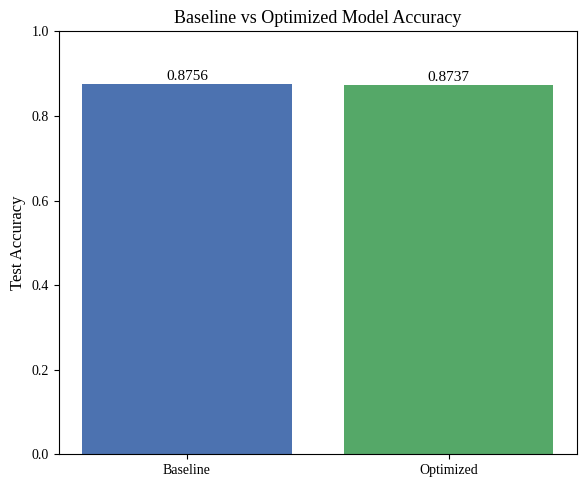

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Baseline', 'Optimized'], [baseline_acc, optimized_acc],
              color=['#4C72B0', '#55A868'])
ax.set_ylabel("Test Accuracy", fontfamily='serif')
ax.set_title("Baseline vs Optimized Model Accuracy", fontfamily='serif')
ax.set_xticklabels(['Baseline', 'Optimized'], fontfamily='serif')
for i, v in enumerate([baseline_acc, optimized_acc]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', fontfamily='serif')
ax.set_ylim(0, 1)
plt.tight_layout()
save_eps(fig, "plot9_best_model_comparison")
plt.show()

In [ ]:
print("Best Hyperparameters:")
print(f"  Hidden Layers        : {best_params['hidden_layers']}")
print(f"  Hidden Neurons       : {best_params['hidden_neurons']}")
print(f"  Learning Rate        : {best_params['learning_rate']}")
print(f"  Batch Size           : {best_params['batch_size']}")
print(f"  Optimizer            : {best_params['optimizer_name']}")
print(f"  Activation Function  : {best_params['activation']}")
print(f"  Epochs               : {best_params['epochs']}")
print(f"  Dropout              : {best_params['dropout_rate']}")
print(f"  Cross-validation Acc.: {best_cv_accuracy:.4f}")
print(f"  Testing Accuracy     : {optimized_acc:.4f}")

print("\nPerformance Comparison Table:")
print(f"{'Metric':<15}{'Baseline':<15}{'Optimized':<15}")
print(f"{'Accuracy':<15}{baseline_acc:<15.4f}{optimized_acc:<15.4f}")
print(f"{'Precision':<15}{baseline_prec:<15.4f}{optimized_prec:<15.4f}")
print(f"{'Recall':<15}{baseline_rec:<15.4f}{optimized_rec:<15.4f}")
print(f"{'F1-score':<15}{baseline_f1:<15.4f}{optimized_f1:<15.4f}")
print(f"{'Train Time(s)':<15}{baseline_train_time:<15.2f}{optimized_train_time:<15.2f}")

Best Hyperparameters:
  Hidden Layers        : 3
  Hidden Neurons       : 128
  Learning Rate        : 0.001
  Batch Size           : 32
  Optimizer            : rmsprop
  Activation Function  : tanh
  Epochs               : 20
  Dropout              : 0.2
  Cross-validation Acc.: 0.8382
  Testing Accuracy     : 0.8737

Performance Comparison Table:
Metric         Baseline       Optimized      
Accuracy       0.8756         0.8737         
Precision      0.8776         0.8773         
Recall         0.8756         0.8737         
F1-score       0.8730         0.8731         
Train Time(s)  86.98          101.43         
